11it [01:15,  6.83s/it]


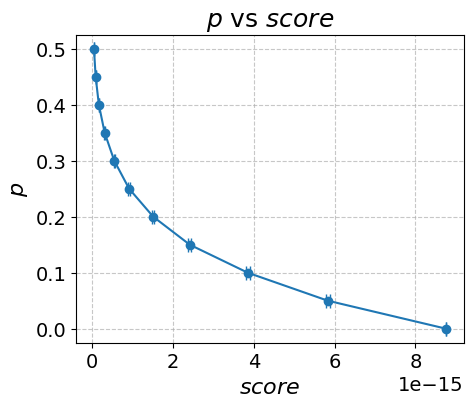

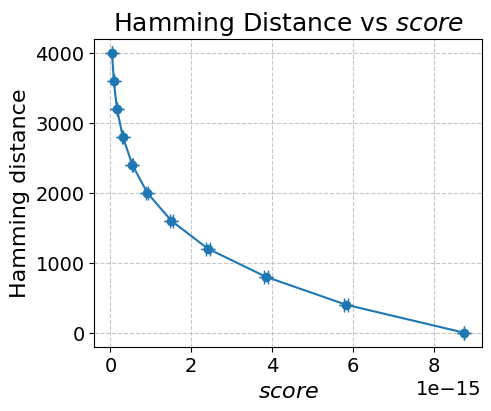

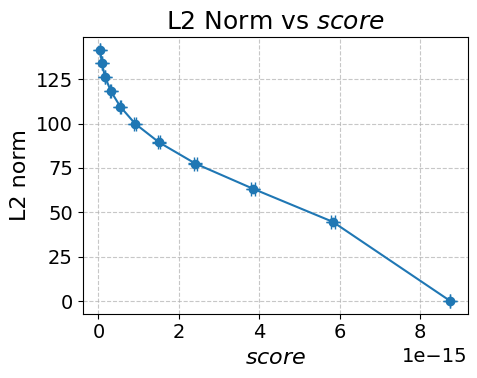

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm
from tqdm import tqdm

def det_ham_l2_for_p1(p, X, Y, d):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = X.copy()
    X_hat[~mask] = np.random.randint(0, d, size=(~mask).sum())
    G_hat = np.zeros((d, d))
    for xh, y in zip(X_hat, Y):
        G_hat[xh, y] += 1
    G_hat /= n
    det_sq = np.linalg.det(G_hat) ** 2
    ham = np.sum(X_hat != X)
    l2 = np.linalg.norm(X_hat - X)
    return det_sq, ham, l2


# Experiment 1 with regular kernel, uniform random manipulation
n = 10000
d = 5
ps = np.arange(0.5, 1.0001, 0.05)
n_runs = 1000

P = np.random.rand(d, d)
P /= P.sum(axis=1, keepdims=True)
X = np.random.randint(0, d, size=n)
Y = np.array([np.random.choice(d, p=P[x]) for x in X])

det_sq_runs = np.zeros((len(ps), n_runs))
ham_runs = np.zeros((len(ps), n_runs))
l2_runs = np.zeros((len(ps), n_runs))

for i, p in tqdm(enumerate(ps)):
    for j in range(n_runs):
        det_sq_runs[i, j], ham_runs[i, j], l2_runs[i, j] = det_ham_l2_for_p1(p, X, Y, d)

def mean_ci(data):
    mean = data.mean(axis=1)
    se = data.std(axis=1, ddof=1) / np.sqrt(n_runs)
    ci = 1.96 * se
    return mean, ci

mean_det, ci_det = mean_ci(det_sq_runs)
mean_ham, ci_ham = mean_ci(ham_runs)
mean_l2, ci_l2 = mean_ci(l2_runs)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, 1 - np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$p$', fontsize=16)
ax.set_title(r'$p$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

11it [01:20,  7.33s/it]


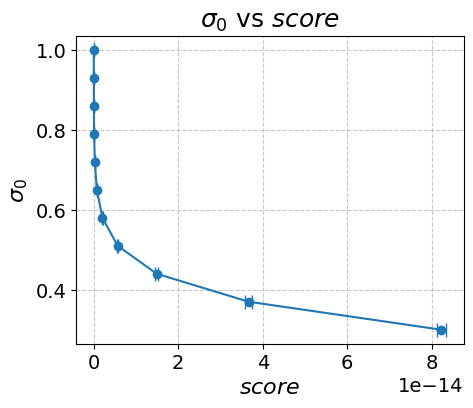

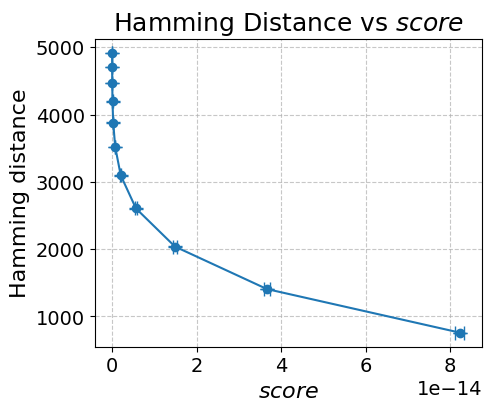

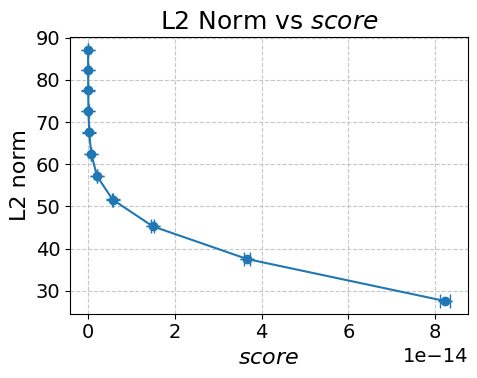

In [ ]:
# Experiment 1 with regular kernel, normal manipulation
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm
from tqdm import tqdm

def det_ham_l2_for_p2(sig, X, Y, d):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=sig, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 0, d-1)

    categories = np.unique(X_hat)
    k = len(categories)
    cat_to_idx = {cat: i for i, cat in enumerate(categories)}
    G_hat = np.zeros((k, d), dtype=float)

    for xh, y in zip(X_hat, Y):
        G_hat[cat_to_idx[xh], y] += 1
    G_hat /= n

    M = G_hat.T.dot(G_hat)
    det_score = np.linalg.det(M)

    ham = np.count_nonzero(X_hat != X)
    l2  = np.linalg.norm(X_hat - X)

    return det_score, ham, l2

n = 10000
d = 5
ps = np.arange(0.3, 1.0001, 0.07)
n_runs = 1000

P = np.random.rand(d, d)
P /= P.sum(axis=1, keepdims=True)
X = np.random.randint(0, d, size=n)
Y = np.array([np.random.choice(d, p=P[x]) for x in X])

det_sq_runs = np.zeros((len(ps), n_runs))
ham_runs = np.zeros((len(ps), n_runs))
l2_runs = np.zeros((len(ps), n_runs))

for i, p in tqdm(enumerate(ps)):
    for j in range(n_runs):
        det_sq_runs[i, j], ham_runs[i, j], l2_runs[i, j] = det_ham_l2_for_p2(p, X, Y, d)

def mean_ci(data):
    mean = data.mean(axis=1)
    se = data.std(axis=1, ddof=1) / np.sqrt(n_runs)
    ci = 1.96 * se
    return mean, ci

mean_det, ci_det = mean_ci(det_sq_runs)
mean_ham, ci_ham = mean_ci(ham_runs)
mean_l2, ci_l2 = mean_ci(l2_runs)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$\sigma_0$', fontsize=16)
ax.set_title(r'$\sigma_0$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

11it [00:39,  3.63s/it]


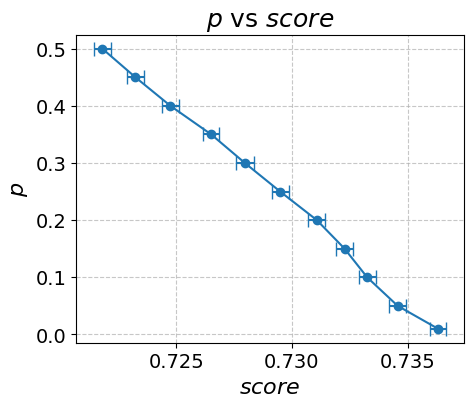

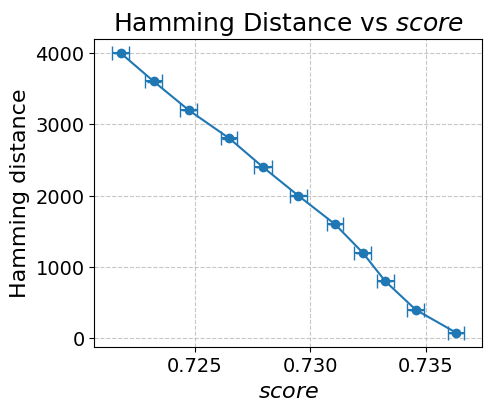

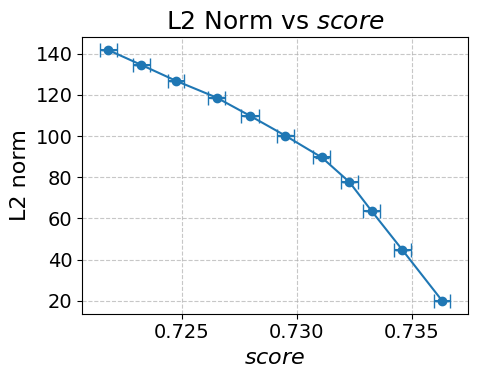

In [ ]:
from tqdm import tqdm
# Experiment 1 with Gaussian kernel, uniform random manipulation

def det_ham_l2_for_p3(p, X, Y, d, sigma = 0.1):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = X.copy()
    X_hat[~mask] = np.random.randint(0, d, size=(~mask).sum())

    categories = np.unique(X_hat)
    k = len(categories)
    G_hat = np.zeros((k, d))
    for i in range(0, k):
        I = np.where(X_hat == i)[0]
        for j in range(0, k):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist


n = 10000
d = 5
ps = np.arange(0.5, 1.0001, 0.05)
ps[-1]=0.99
n_runs = 1000

P = np.random.rand(d, d)
P /= P.sum(axis=1, keepdims=True)
X = np.random.randint(0, d, size=n)
Y = np.array([np.random.choice(d, p=P[x]) for x in X])

det_sq_runs = np.zeros((len(ps), n_runs))
ham_runs = np.zeros((len(ps), n_runs))
l2_runs = np.zeros((len(ps), n_runs))

for i, p in tqdm(enumerate(ps)):
    for j in range(n_runs):
        det_sq_runs[i, j], ham_runs[i, j], l2_runs[i, j] = det_ham_l2_for_p3(p, X, Y, d)

def mean_ci(data):
    mean = data.mean(axis=1)
    se = data.std(axis=1, ddof=1) / np.sqrt(n_runs)
    ci = 1.96 * se
    return mean, ci

mean_det, ci_det = mean_ci(det_sq_runs)
mean_ham, ci_ham = mean_ci(ham_runs)
mean_l2, ci_l2 = mean_ci(l2_runs)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, 1 - np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$p$', fontsize=16)
ax.set_title(r'$p$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

11it [01:20,  7.30s/it]


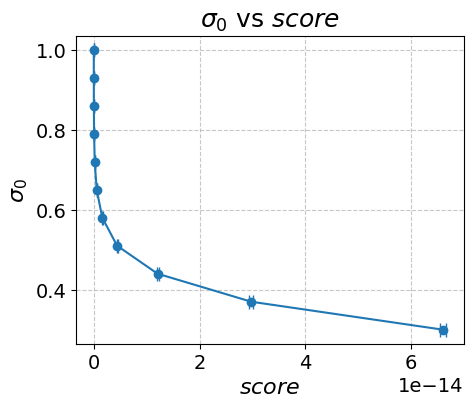

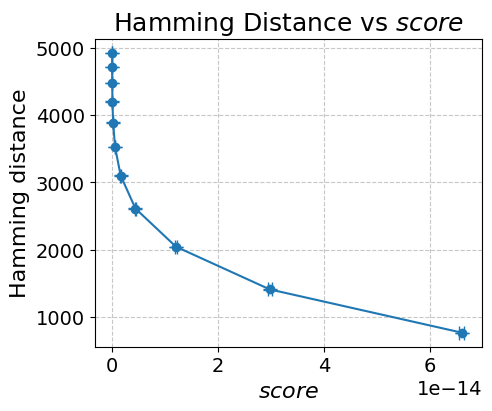

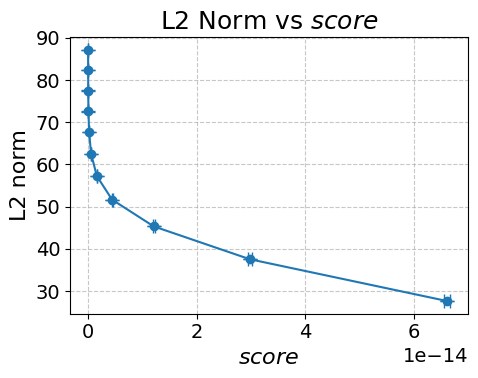

In [ ]:
# Experiment 1 with Gaussian kernel, normal manipulation

def det_ham_l2_for_p4(sig, X, Y, d, sigma = 0.1):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=sig, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 0, d-1)

    G_hat = np.zeros((d, d))
    for i in range(0, d):
        I = np.where(X_hat == i)[0]
        for j in range(0, d):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist


n = 10000
d = 5
ps = np.arange(0.3, 1.0001, 0.07)
n_runs = 1000

P = np.random.rand(d, d)
P /= P.sum(axis=1, keepdims=True)
X = np.random.randint(0, d, size=n)
Y = np.array([np.random.choice(d, p=P[x]) for x in X])

det_sq_runs = np.zeros((len(ps), n_runs))
ham_runs = np.zeros((len(ps), n_runs))
l2_runs = np.zeros((len(ps), n_runs))

for i, p in tqdm(enumerate(ps)):
    for j in range(n_runs):
        det_sq_runs[i, j], ham_runs[i, j], l2_runs[i, j] = det_ham_l2_for_p2(p, X, Y, d)

def mean_ci(data):
    mean = data.mean(axis=1)
    se = data.std(axis=1, ddof=1) / np.sqrt(n_runs)
    ci = 1.96 * se
    return mean, ci

mean_det, ci_det = mean_ci(det_sq_runs)
mean_ham, ci_ham = mean_ci(ham_runs)
mean_l2, ci_l2 = mean_ci(l2_runs)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$\sigma_0$', fontsize=16)
ax.set_title(r'$\sigma_0$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

11it [00:05,  1.87it/s]


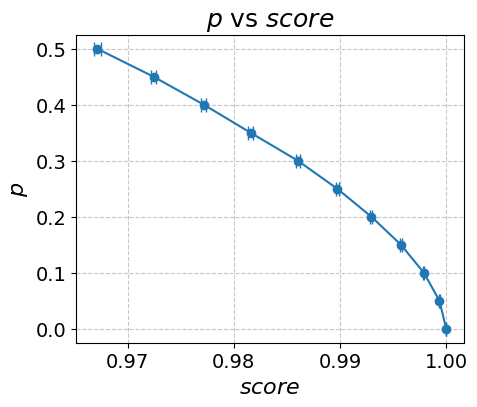

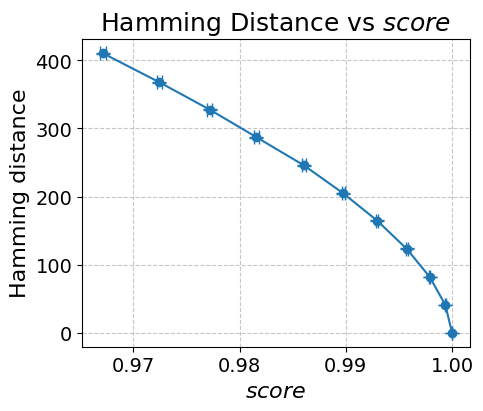

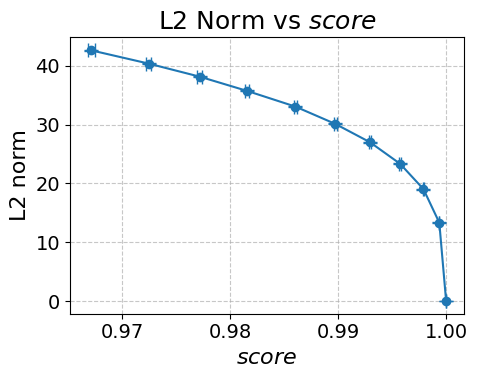

In [ ]:
# Experiment 2 with Gaussian kernel and uniform random manipulation

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm
from tqdm import tqdm

def score1(p, X, Y, sigma, d):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = X.copy()
    X_hat[~mask] = np.random.randint(0, d, size=(~mask).sum())

    G_hat = np.zeros((d, d))
    for i in range(1, d+1):
        I = np.where(X_hat == i)[0]
        for j in range(1, d+1):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist

n, d, sigma = 1000, 4, 0.1
ps = np.arange(0.5, 1.01, 0.05)
trials = 1000

np.random.seed(42)
X = np.random.randint(1, d+1, size=n)
Y = X + np.random.normal(loc=0, scale=sigma, size=n)

scores_all = np.zeros((len(ps), trials))
hammings_all = np.zeros((len(ps), trials))
l2s_all = np.zeros((len(ps), trials))

for i, p in tqdm(enumerate(ps)):
    for t in range(trials):
        s, h, l2 = score1(p, X, Y, sigma, d)
        scores_all[i, t] = s
        hammings_all[i, t] = h
        l2s_all[i, t] = l2

def mean_ci(data):
    mean = data.mean(axis=1)
    stderr = data.std(axis=1, ddof=1) / np.sqrt(data.shape[1])
    ci = 1.96 * stderr
    return mean, ci

mean_det, ci_det = mean_ci(scores_all)
mean_ham, ci_ham = mean_ci(hammings_all)
mean_l2, ci_l2 = mean_ci(l2s_all)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, np.ones(len(ps))-np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$p$', fontsize=16)
ax.set_title(r'$p$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

11it [00:07,  1.44it/s]


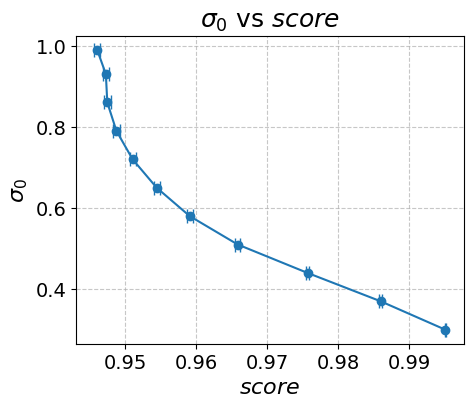

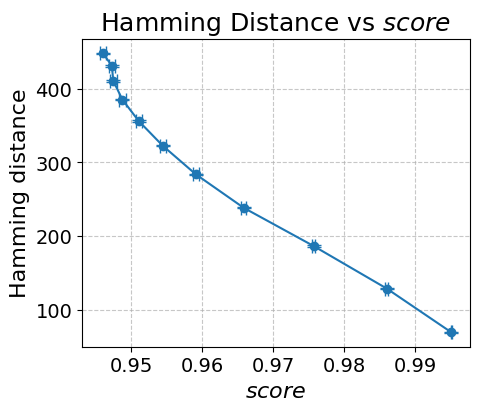

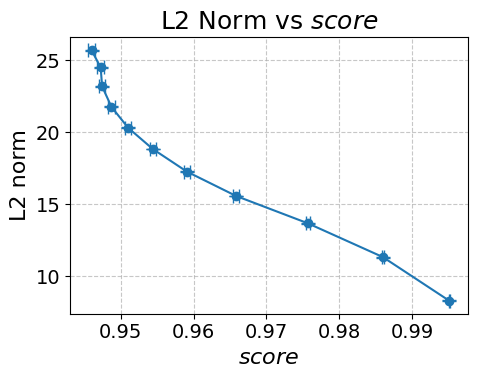

In [ ]:
# Experiment 2 with Gaussian kernel and normal manipulation

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm
from tqdm import tqdm

def score2(sig, X, Y, sigma, d):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=sig, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 1, d)

    G_hat = np.zeros((d, d))
    for i in range(1, d+1):
        I = np.where(X_hat == i)[0]
        for j in range(1, d+1):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist

n, d, sigma = 1000, 4, 0.1
ps = np.arange(0.3, 1.0001, 0.07)
ps[-1] = 0.99
trials = 1000

np.random.seed(42)
X = np.random.randint(1, d+1, size=n)
Y = X + np.random.normal(loc=0, scale=sigma, size=n)

scores_all = np.zeros((len(ps), trials))
hammings_all = np.zeros((len(ps), trials))
l2s_all = np.zeros((len(ps), trials))

for i, p in tqdm(enumerate(ps)):
    for t in range(trials):
        s, h, l2 = score2(p, X, Y, sigma, d)
        scores_all[i, t] = s
        hammings_all[i, t] = h
        l2s_all[i, t] = l2

def mean_ci(data):
    mean = data.mean(axis=1)
    stderr = data.std(axis=1, ddof=1) / np.sqrt(data.shape[1])
    ci = 1.96 * stderr
    return mean, ci

mean_det, ci_det = mean_ci(scores_all)
mean_ham, ci_ham = mean_ci(hammings_all)
mean_l2, ci_l2 = mean_ci(l2s_all)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$\sigma_0$', fontsize=16)
ax.set_title(r'$\sigma_0$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

11it [00:13,  1.24s/it]


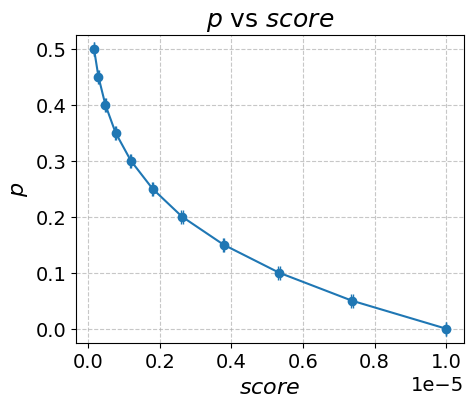

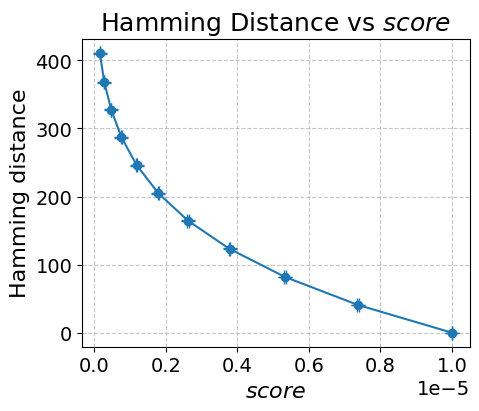

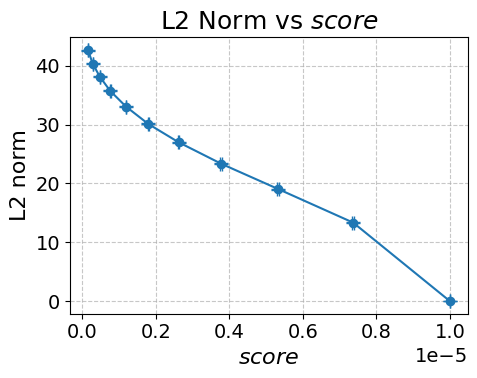

In [ ]:
# Experiment 2 with Delta kernel and uniform random manipulation

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm
from tqdm import tqdm

def score_delta(p, X, Y, sigma, d):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = X.copy()
    X_hat[~mask] = np.random.randint(0, d, size=(~mask).sum())
    G_hat = np.zeros((d, d))
    quantiles = np.linspace(0, 1, d+1)
    bins = np.quantile(Y, quantiles)
    Y_bucket = np.digitize(Y, bins[1:-1], right=True) + 1
    for xh, y in zip(X_hat, Y_bucket):
        G_hat[xh - 1, y - 1] += 1
    G_hat /= n
    det_sq = np.linalg.det(G_hat)**2
    ham = np.sum(X_hat != X)
    l2 = np.linalg.norm(X_hat - X)
    return det_sq, ham, l2

n, d, sigma = 1000, 4, 0.1
ps = np.arange(0.5, 1.01, 0.05)
trials = 1000

np.random.seed(42)
X = np.random.randint(1, d+1, size=n)
Y = X + np.random.normal(loc=0, scale=sigma, size=n)

scores_all = np.zeros((len(ps), trials))
hammings_all = np.zeros((len(ps), trials))
l2s_all = np.zeros((len(ps), trials))

for i, p in tqdm(enumerate(ps)):
    for t in range(trials):
        s, h, l2 = score_delta(p, X, Y, sigma, d)
        scores_all[i, t] = s
        hammings_all[i, t] = h
        l2s_all[i, t] = l2

def mean_ci(data):
    mean = data.mean(axis=1)
    stderr = data.std(axis=1, ddof=1) / np.sqrt(data.shape[1])
    ci = 1.96 * stderr
    return mean, ci

mean_det, ci_det = mean_ci(scores_all)
mean_ham, ci_ham = mean_ci(hammings_all)
mean_l2, ci_l2 = mean_ci(l2s_all)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, np.ones(len(ps))-np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$p$', fontsize=16)
ax.set_title(r'$p$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

11it [00:13,  1.23s/it]


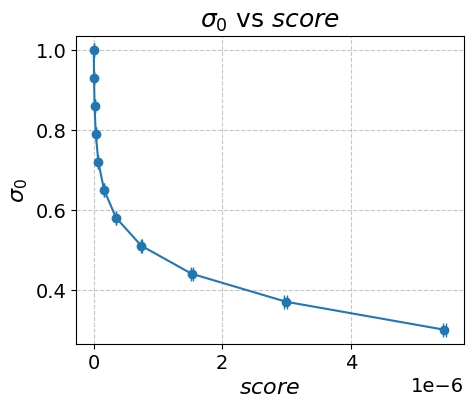

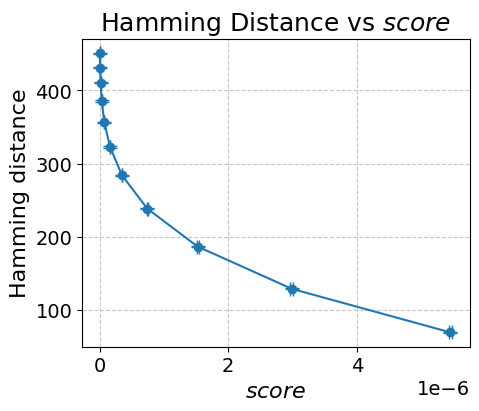

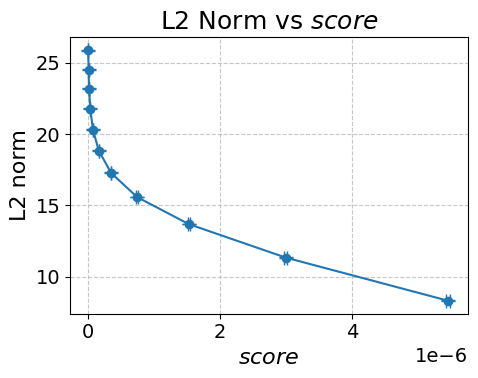

In [ ]:
# Experiment 2 with Delta kernel and normal manipulation

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm
from tqdm import tqdm

def score_delta(p, X, Y, sigma, d):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=p, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 1, d)

    G_hat = np.zeros((d, d))
    quantiles = np.linspace(0, 1, d+1)
    bins = np.quantile(Y, quantiles)
    Y_bucket = np.digitize(Y, bins[1:-1], right=True) + 1
    for xh, y in zip(X_hat, Y_bucket):
        G_hat[xh - 1, y - 1] += 1
    G_hat /= n
    det_sq = np.linalg.det(G_hat)**2
    ham = np.sum(X_hat != X)
    l2 = np.linalg.norm(X_hat - X)
    return det_sq, ham, l2

n, d, sigma = 1000, 4, 0.1
ps = np.arange(0.3, 1.01, 0.07)
trials = 1000

np.random.seed(42)
X = np.random.randint(1, d+1, size=n)
Y = X + np.random.normal(loc=0, scale=sigma, size=n)

scores_all = np.zeros((len(ps), trials))
hammings_all = np.zeros((len(ps), trials))
l2s_all = np.zeros((len(ps), trials))

for i, p in tqdm(enumerate(ps)):
    for t in range(trials):
        s, h, l2 = score_delta(p, X, Y, sigma, d)
        scores_all[i, t] = s
        hammings_all[i, t] = h
        l2s_all[i, t] = l2

def mean_ci(data):
    mean = data.mean(axis=1)
    stderr = data.std(axis=1, ddof=1) / np.sqrt(data.shape[1])
    ci = 1.96 * stderr
    return mean, ci

mean_det, ci_det = mean_ci(scores_all)
mean_ham, ci_ham = mean_ci(hammings_all)
mean_l2, ci_l2 = mean_ci(l2s_all)

import matplotlib.pyplot as plt

# Make text larger and configure grid appearance
plt.rcParams.update({'font.size': 14})

# Example size: smaller figure (4×3 inches)
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, np.array(ps), xerr=ci_det, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel(r'$\sigma_0$', fontsize=16)
ax.set_title(r'$\sigma_0$ vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_ham, xerr=ci_det, yerr=ci_ham, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('Hamming distance', fontsize=16)
ax.set_title(r'Hamming Distance vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(mean_det, mean_l2, xerr=ci_det, yerr=ci_l2, fmt='-o', capsize=5)
ax.set_xlabel(r'$score$', fontsize=16)
ax.set_ylabel('L2 norm', fontsize=16)
ax.set_title(r'L2 Norm vs $score$', fontsize=18)
ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [01:49<00:00,  9.13it/s]


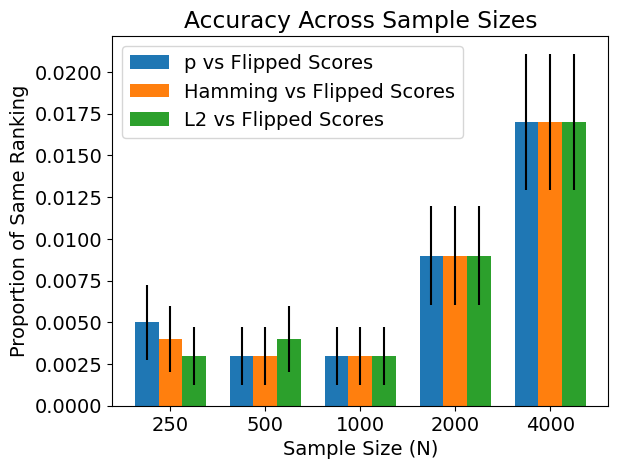

In [ ]:
# Experiment 1 with uniform random manipulation

import numpy as np
from tqdm import trange
import matplotlib.pyplot as plt
from numpy.linalg import det, norm

def score_gaussian(p, X, Y, sigma, d):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = np.where(mask, X, np.random.randint(1, d+1, size=n))

    G_hat = np.zeros((d, d))
    for i in range(1, d+1):
        I = np.where(X_hat == i)[0]
        for j in range(1, d+1):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist

def score_delta(p, X, Y, d):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = X.copy()
    X_hat[~mask] = np.random.randint(0, d, size=(~mask).sum())
    G_hat = np.zeros((d, d))
    for xh, y in zip(X_hat, Y):
        G_hat[xh - 1, y - 1] += 1
    G_hat /= n
    det_sq = np.linalg.det(G_hat)**2
    ham = np.sum(X_hat != X)
    l2 = np.linalg.norm(X_hat - X)
    return det_sq, ham, l2

def same_ranking(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        raise ValueError("a and b must be the same length")
    return np.argsort(a).tolist() == np.argsort(b).tolist()

def reliability_metric_correspondence(n = 10, d = 5, sigma = 0.1):
    ps = np.arange(0.5, 1.01, 0.1)
    P = np.random.rand(d, d)
    P /= P.sum(axis=1, keepdims=True)
    X = np.random.randint(0, d, size=n)
    Y = np.array([np.random.choice(d, p=P[x]) for x in X])
    X = X + np.ones(len(X))
    X = np.array([int(x) for x in X])
    Y = Y + np.ones(len(Y))
    Y = np.array([int(y) for y in Y])

    scores_all = np.zeros(len(ps))
    hammings_all = np.zeros(len(ps))
    l2s_all = np.zeros(len(ps))

    for i, p in enumerate(ps):
        # s, h, l2 = score_delta(p, X, Y, d)
        s, h, l2 = score_gaussian(p, X, Y, sigma, d)
        scores_all[i] = s
        hammings_all[i] = h
        l2s_all[i] = l2

    return same_ranking(ps, scores_all), same_ranking(hammings_all, np.flip(scores_all)), same_ranking(l2s_all, np.flip(scores_all))

n_list = [250, 500, 1000, 2000, 4000]
d = 5
sigma = 0.1
trials = 1000

results = {'ps_scores': [], 'hamming_scores': [], 'l2_scores': []}

for n in n_list:
    ps_scores = []
    hamming_scores = []
    l2_scores = []
    for _ in trange(trials):
        scores_all, hammings_all, l2s_all = reliability_metric_correspondence(n, d, sigma)
        ps_scores.append(scores_all)
        hamming_scores.append(hammings_all)
        l2_scores.append(l2s_all)
    results['ps_scores'].append(ps_scores)
    results['hamming_scores'].append(hamming_scores)
    results['l2_scores'].append(l2_scores)

means = {k: [np.mean(v) for v in results[k]] for k in results}
stderr = {k: [np.std(v, ddof=1) / np.sqrt(trials) for v in results[k]] for k in results}

x = np.arange(len(n_list))
width = 0.25

plt.figure()
plt.bar(x - width, means['ps_scores'], width, yerr=stderr['ps_scores'], label='p vs Flipped Scores')
plt.bar(x, means['hamming_scores'], width, yerr=stderr['hamming_scores'], label='Hamming vs Flipped Scores')
plt.bar(x + width, means['l2_scores'], width, yerr=stderr['l2_scores'], label='L2 vs Flipped Scores')
plt.xticks(x, n_list)
plt.xlabel('Sample Size (N)')
plt.ylabel('Proportion of Same Ranking')
plt.legend()
plt.title('Accuracy Across Sample Sizes')
plt.show()

100%|██████████| 1000/1000 [01:50<00:00,  9.02it/s]


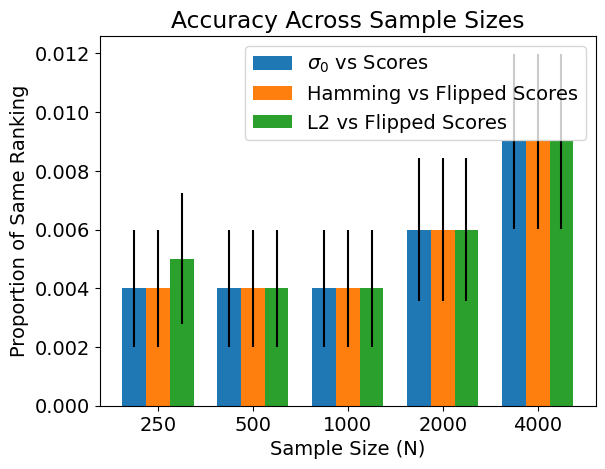

In [ ]:
# Experiment 1 with normal manipulation

import numpy as np
from tqdm import trange
import matplotlib.pyplot as plt
from numpy.linalg import det, norm

def score_gaussian(p, X, Y, sigma, d):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=p, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 1, d)

    G_hat = np.zeros((d, d))
    for i in range(1, d+1):
        I = np.where(X_hat == i)[0]
        for j in range(1, d+1):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist

def score_delta(p, X, Y, d):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=p, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 1, d)
    G_hat = np.zeros((d, d))
    for xh, y in zip(X_hat, Y):
        G_hat[xh - 1, y - 1] += 1
    G_hat /= n
    det_sq = np.linalg.det(G_hat)**2
    ham = np.sum(X_hat != X)
    l2 = np.linalg.norm(X_hat - X)
    return det_sq, ham, l2

def same_ranking(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        raise ValueError("a and b must be the same length")
    return np.argsort(a).tolist() == np.argsort(b).tolist()

def reliability_metric_correspondence(n = 10, d = 5, sigma = 0.1):
    ps = np.arange(0.3, 1.01, 0.14)
    P = np.random.rand(d, d)
    P /= P.sum(axis=1, keepdims=True)
    X = np.random.randint(0, d, size=n)
    Y = np.array([np.random.choice(d, p=P[x]) for x in X])
    X = X + np.ones(len(X))
    X = np.array([int(x) for x in X])
    Y = Y + np.ones(len(Y))
    Y = np.array([int(y) for y in Y])

    scores_all = np.zeros(len(ps))
    hammings_all = np.zeros(len(ps))
    l2s_all = np.zeros(len(ps))

    for i, p in enumerate(ps):
        # s, h, l2 = score_delta(p, X, Y, d)
        s, h, l2 = score_gaussian(p, X, Y, sigma, d)
        scores_all[i] = s
        hammings_all[i] = h
        l2s_all[i] = l2

    return same_ranking(ps, np.flip(scores_all)), same_ranking(hammings_all, np.flip(scores_all)), same_ranking(l2s_all, np.flip(scores_all))

n_list = [250, 500, 1000, 2000, 4000]
d = 5
sigma = 0.1
trials = 1000

results = {'ps_scores': [], 'hamming_scores': [], 'l2_scores': []}

for n in n_list:
    ps_scores = []
    hamming_scores = []
    l2_scores = []
    for _ in trange(trials):
        scores_all, hammings_all, l2s_all = reliability_metric_correspondence(n, d, sigma)
        ps_scores.append(scores_all)
        hamming_scores.append(hammings_all)
        l2_scores.append(l2s_all)
    results['ps_scores'].append(ps_scores)
    results['hamming_scores'].append(hamming_scores)
    results['l2_scores'].append(l2_scores)

means = {k: [np.mean(v) for v in results[k]] for k in results}
stderr = {k: [np.std(v, ddof=1) / np.sqrt(trials) for v in results[k]] for k in results}

x = np.arange(len(n_list))
width = 0.25

plt.figure()
plt.bar(x - width, means['ps_scores'], width, yerr=stderr['ps_scores'], label=r'$\sigma_0$ vs Scores')
plt.bar(x, means['hamming_scores'], width, yerr=stderr['hamming_scores'], label='Hamming vs Flipped Scores')
plt.bar(x + width, means['l2_scores'], width, yerr=stderr['l2_scores'], label='L2 vs Flipped Scores')
plt.xticks(x, n_list)
plt.xlabel('Sample Size (N)')
plt.ylabel('Proportion of Same Ranking')
plt.legend()
plt.title('Accuracy Across Sample Sizes')
plt.show()

100%|██████████| 1000/1000 [00:06<00:00, 143.93it/s]


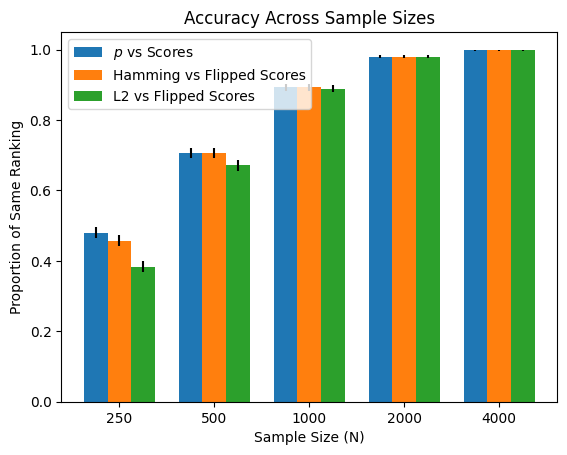

In [ ]:
# Experiment 2 with uniform random manipulation

import numpy as np
from tqdm import trange
import matplotlib.pyplot as plt
from numpy.linalg import det, norm

def score_gaussian(p, X, Y, sigma, d):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = np.where(mask, X, np.random.randint(1, d+1, size=n))

    G_hat = np.zeros((d, d))
    for i in range(1, d+1):
        I = np.where(X_hat == i)[0]
        for j in range(1, d+1):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist

def score_delta(p, X, Y, sigma, d):
    n = len(X)
    mask = np.random.rand(n) < p
    X_hat = X.copy()
    X_hat[~mask] = np.random.randint(0, d, size=(~mask).sum())
    G_hat = np.zeros((d, d))
    quantiles = np.linspace(0, 1, d+1)
    bins = np.quantile(Y, quantiles)
    Y_bucket = np.digitize(Y, bins[1:-1], right=True) + 1
    for xh, y in zip(X_hat, Y_bucket):
        G_hat[xh - 1, y - 1] += 1
    G_hat /= n
    det_sq = np.linalg.det(G_hat)**2
    ham = np.sum(X_hat != X)
    l2 = np.linalg.norm(X_hat - X)
    return det_sq, ham, l2

def same_ranking(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        raise ValueError("a and b must be the same length")
    return np.argsort(a).tolist() == np.argsort(b).tolist()

def reliability_metric_correspondence(n = 10, d = 4, sigma = 0.1):
    ps = np.arange(0.5, 1.01, 0.1)
    X = np.random.randint(1, d+1, size=n)
    Y = X + np.random.normal(loc=0, scale=sigma, size=n)

    scores_all = np.zeros(len(ps))
    hammings_all = np.zeros(len(ps))
    l2s_all = np.zeros(len(ps))

    for i, p in enumerate(ps):
        # s, h, l2 = score_delta(p, X, Y, sigma, d)
        s, h, l2 = score_gaussian(p, X, Y, sigma, d)
        scores_all[i] = s
        hammings_all[i] = h
        l2s_all[i] = l2

    return same_ranking(ps, scores_all), same_ranking(hammings_all, np.flip(scores_all)), same_ranking(l2s_all, np.flip(scores_all))

n_list = [250, 500, 1000, 2000, 4000]
d = 4
sigma = 0.1
trials = 1000

results = {'ps_scores': [], 'hamming_scores': [], 'l2_scores': []}

for n in n_list:
    ps_scores = []
    hamming_scores = []
    l2_scores = []
    for _ in trange(trials):
        scores_all, hammings_all, l2s_all = reliability_metric_correspondence(n, d, sigma)
        ps_scores.append(scores_all)
        hamming_scores.append(hammings_all)
        l2_scores.append(l2s_all)
    results['ps_scores'].append(ps_scores)
    results['hamming_scores'].append(hamming_scores)
    results['l2_scores'].append(l2_scores)

# Compute means and standard errors
means = {k: [np.mean(v) for v in results[k]] for k in results}
stderr = {k: [np.std(v, ddof=1) / np.sqrt(trials) for v in results[k]] for k in results}

x = np.arange(len(n_list))
width = 0.25

plt.figure()
plt.bar(x - width, means['ps_scores'], width, yerr=stderr['ps_scores'], label=r'$p$ vs Scores')
plt.bar(x, means['hamming_scores'], width, yerr=stderr['hamming_scores'], label='Hamming vs Flipped Scores')
plt.bar(x + width, means['l2_scores'], width, yerr=stderr['l2_scores'], label='L2 vs Flipped Scores')
plt.xticks(x, n_list)
plt.xlabel('Sample Size (N)')
plt.ylabel('Proportion of Same Ranking')
plt.legend()
plt.title('Accuracy Across Sample Sizes')
plt.show()

100%|██████████| 1000/1000 [00:23<00:00, 41.67it/s]


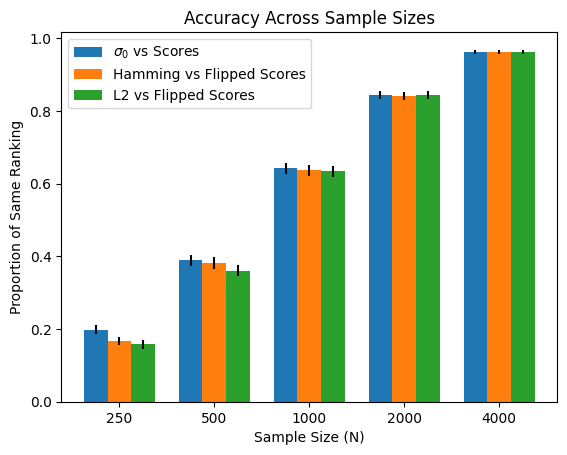

In [ ]:
# Experiment 2 with normal manipulation

import numpy as np
from tqdm import trange
import matplotlib.pyplot as plt
from numpy.linalg import det, norm

def score_gaussian(p, X, Y, sigma, d):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=p, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 1, d)

    G_hat = np.zeros((d, d))
    for i in range(1, d+1):
        I = np.where(X_hat == i)[0]
        for j in range(1, d+1):
            J = np.where(X_hat == j)[0]
            if I.size and J.size:
                Yi = Y[I]
                Yj = Y[J]
                sqdist = (Yi[:min(I.size, J.size)] - Yj[:min(I.size, J.size)])**2
                G_hat[i-1, j-1] = np.mean(np.exp(-sqdist / sigma**2))

    score_val = det(G_hat)
    hamming = np.count_nonzero(X_hat != X)
    l2_dist = norm(X_hat - X)
    return score_val, hamming, l2_dist

def score_delta(p, X, Y, sigma, d):
    n = len(X)
    noise = np.random.normal(loc=0.0, scale=p, size=n)
    X_hat = np.round(X + noise).astype(int)
    X_hat = np.clip(X_hat, 1, d)
    G_hat = np.zeros((d, d))
    quantiles = np.linspace(0, 1, d+1)
    bins = np.quantile(Y, quantiles)
    Y_bucket = np.digitize(Y, bins[1:-1], right=True) + 1
    for xh, y in zip(X_hat, Y_bucket):
        G_hat[xh - 1, y - 1] += 1
    G_hat /= n
    det_sq = np.linalg.det(G_hat)**2
    ham = np.sum(X_hat != X)
    l2 = np.linalg.norm(X_hat - X)
    return det_sq, ham, l2

def same_ranking(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        raise ValueError("a and b must be the same length")
    return np.argsort(a).tolist() == np.argsort(b).tolist()

def reliability_metric_correspondence(n = 10, d = 4, sigma = 0.1):
    ps = np.arange(0.5, 1.01, 0.1)
    X = np.random.randint(1, d+1, size=n)
    Y = X + np.random.normal(loc=0, scale=sigma, size=n)

    scores_all = np.zeros(len(ps))
    hammings_all = np.zeros(len(ps))
    l2s_all = np.zeros(len(ps))

    for i, p in enumerate(ps):
        s, h, l2 = score_delta(p, X, Y, sigma, d)
        # s, h, l2 = score_gaussian(p, X, Y, sigma, d)
        scores_all[i] = s
        hammings_all[i] = h
        l2s_all[i] = l2

    return same_ranking(ps, np.flip(scores_all)), same_ranking(hammings_all, np.flip(scores_all)), same_ranking(l2s_all, np.flip(scores_all))

n_list = [250, 500, 1000, 2000, 4000]
d = 4
sigma = 0.1
trials = 1000

results = {'ps_scores': [], 'hamming_scores': [], 'l2_scores': []}

for n in n_list:
    ps_scores = []
    hamming_scores = []
    l2_scores = []
    for _ in trange(trials):
        scores_all, hammings_all, l2s_all = reliability_metric_correspondence(n, d, sigma)
        ps_scores.append(scores_all)
        hamming_scores.append(hammings_all)
        l2_scores.append(l2s_all)
    results['ps_scores'].append(ps_scores)
    results['hamming_scores'].append(hamming_scores)
    results['l2_scores'].append(l2_scores)

# Compute means and standard errors
means = {k: [np.mean(v) for v in results[k]] for k in results}
stderr = {k: [np.std(v, ddof=1) / np.sqrt(trials) for v in results[k]] for k in results}

x = np.arange(len(n_list))
width = 0.25

plt.figure()
plt.bar(x - width, means['ps_scores'], width, yerr=stderr['ps_scores'], label=r'$\sigma_0$ vs Scores')
plt.bar(x, means['hamming_scores'], width, yerr=stderr['hamming_scores'], label='Hamming vs Flipped Scores')
plt.bar(x + width, means['l2_scores'], width, yerr=stderr['l2_scores'], label='L2 vs Flipped Scores')
plt.xticks(x, n_list)
plt.xlabel('Sample Size (N)')
plt.ylabel('Proportion of Same Ranking')
plt.legend()
plt.title('Accuracy Across Sample Sizes')
plt.show()